In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import os

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving api_data_aadhar_enrolment.zip to api_data_aadhar_enrolment.zip


In [4]:
import zipfile
import os

zip_path = "api_data_aadhar_enrolment.zip"
assert zip_path in uploaded, "ZIP file not uploaded!"

extract_path = "aadhar_data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")
!ls aadhar_data

Extraction completed.
api_data_aadhar_enrolment


In [5]:
import pandas as pd
import glob

csv_files = sorted(
    glob.glob("aadhar_data/api_data_aadhar_enrolment/*.csv")
)

if not csv_files:
    raise FileNotFoundError("No CSV files found!")

df = pd.concat(
    (pd.read_csv(f) for f in csv_files),
    ignore_index=True
)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1006029, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB


,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0


In [7]:
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y")
df['state'] = df['state'].str.strip().str.title()
df['district'] = df['district'].str.strip().str.title()

df = df.dropna(subset=['state', 'district'])

df[['age_0_5', 'age_5_17', 'age_18_greater']] = (
    df[['age_0_5', 'age_5_17', 'age_18_greater']].fillna(0)
)

In [8]:
df['total_enrolments'] = (
    df['age_0_5'] + df['age_5_17'] + df['age_18_greater']
)

df[['date', 'state', 'total_enrolments']].head()

age_long = df.melt(
    id_vars=['date', 'state'],
    value_vars=['age_0_5', 'age_5_17', 'age_18_greater'],
    var_name='age_group',
    value_name='count'
)

age_long.head()

,date,state,age_group,count
0,2025-03-02,Meghalaya,age_0_5,11
1,2025-03-09,Karnataka,age_0_5,14
2,2025-03-09,Uttar Pradesh,age_0_5,29
3,2025-03-09,Uttar Pradesh,age_0_5,62
4,2025-03-09,Karnataka,age_0_5,14


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

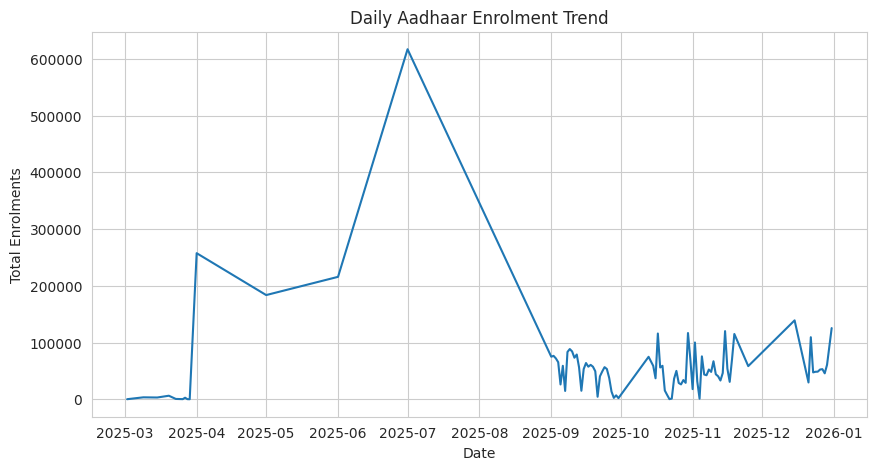

In [10]:
daily_trend = df.groupby('date')['total_enrolments'].sum()

plt.plot(daily_trend)
plt.title("Daily Aadhaar Enrolment Trend")
plt.xlabel("Date")
plt.ylabel("Total Enrolments")
plt.show()

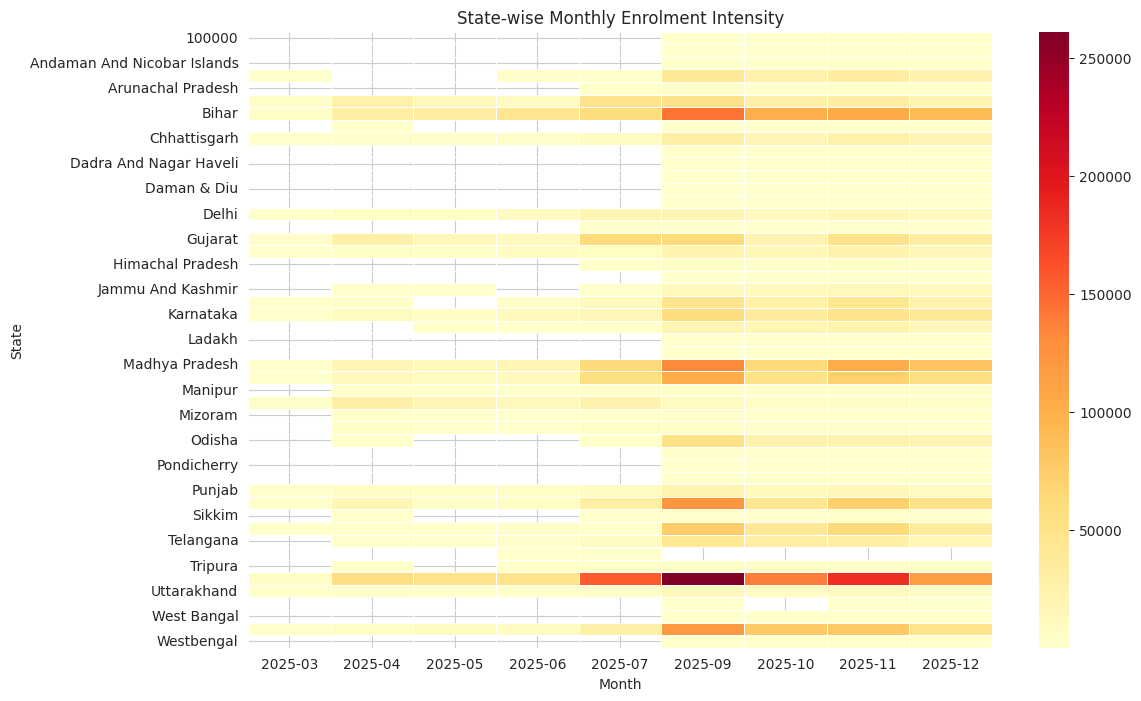

In [12]:
# Create month column
df['month'] = df['date'].dt.to_period('M').astype(str)

state_month = df.pivot_table(
    index='state',
    columns='month',
    values='total_enrolments',
    aggfunc='sum'
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    state_month,
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title("State-wise Monthly Enrolment Intensity")
plt.xlabel("Month")
plt.ylabel("State")
plt.show()

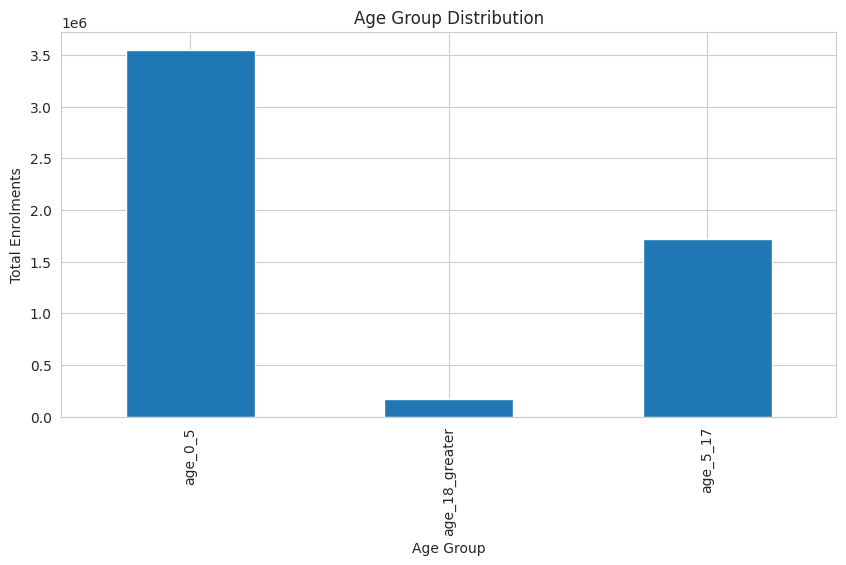

In [13]:
age_summary = age_long.groupby('age_group')['count'].sum()

age_summary.plot(kind='bar')
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Total Enrolments")
plt.show()

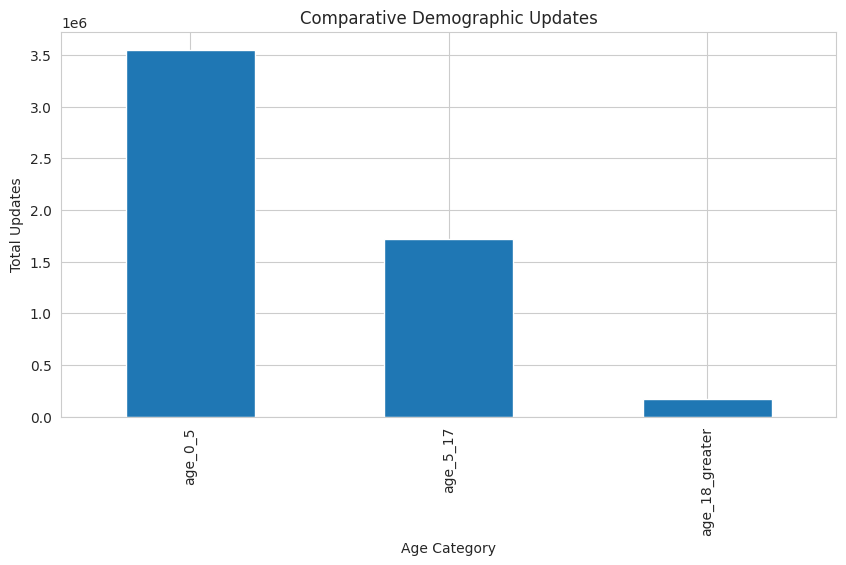

In [14]:
df[['age_0_5', 'age_5_17', 'age_18_greater']].sum().plot(kind='bar')
plt.title("Comparative Demographic Updates")
plt.xlabel("Age Category")
plt.ylabel("Total Updates")
plt.show()

Number of anomalies detected: 2962


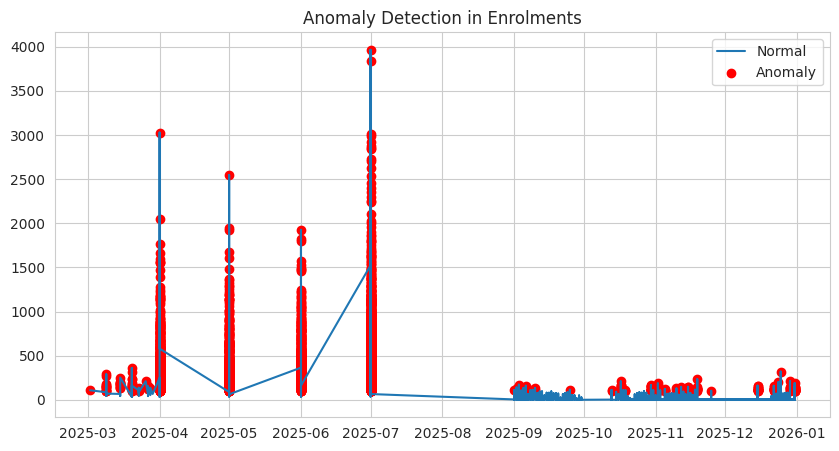

In [15]:
from scipy.stats import zscore

df['z_score'] = zscore(df['total_enrolments'])
anomalies = df[df['z_score'].abs() > 3]

print("Number of anomalies detected:", anomalies.shape[0])

plt.plot(df['date'], df['total_enrolments'], label="Normal")
plt.scatter(
    anomalies['date'],
    anomalies['total_enrolments'],
    color='red',
    label='Anomaly'
)
plt.legend()
plt.title("Anomaly Detection in Enrolments")
plt.show()

In [16]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrolments,month,z_score
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,2025-03,3.280174
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,2025-03,2.551928
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,2025-03,3.723454
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,2025-03,3.185186
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,2025-03,1.443728


In [17]:
# Monthly aggregation for 3D visualization
df['month'] = df['date'].dt.to_period('M').astype(str)

state_month_3d = (
    df.groupby(['state', 'month'])['total_enrolments']
    .sum()
    .reset_index()
)

state_month_3d.head()

,state,month,total_enrolments
0,100000,2025-09,12
1,100000,2025-10,1
2,100000,2025-11,11
3,100000,2025-12,194
4,Andaman & Nicobar Islands,2025-09,43


In [18]:
import plotly.express as px

fig = px.scatter_3d(
    state_month_3d,
    x='state',
    y='month',
    z='total_enrolments',
    color='total_enrolments',
    title='3D View: State-wise Monthly Aadhaar Enrolments',
    color_continuous_scale='YlOrRd'
)

fig.update_layout(
    scene=dict(
        xaxis_title='State',
        yaxis_title='Month',
        zaxis_title='Total Enrolments'
    )
)

fig.show()

In [19]:
# Select top 10 states
top_states = (
    df.groupby('state')['total_enrolments']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

filtered_3d = state_month_3d[state_month_3d['state'].isin(top_states)]

fig = px.scatter_3d(
    filtered_3d,
    x='state',
    y='month',
    z='total_enrolments',
    color='state',
    title='3D Enrolment Trends (Top 10 States)'
)

fig.show()

In [21]:
import plotly.graph_objects as go

# Prepare pivot table (Top 10 states recommended)
pivot_3d = filtered_3d.pivot(
    index='state',
    columns='month',
    values='total_enrolments'
)

fig = go.Figure(
    data=[
        go.Surface(
            z=pivot_3d.values,
            x=pivot_3d.columns,
            y=pivot_3d.index,
            colorscale='Viridis'
        )
    ]
)

fig.update_layout(
    title='3D Surface: Enrolment Intensity Across States and Months',
    scene=dict(
        xaxis_title='Month',
        yaxis_title='State',
        zaxis_title='Total Enrolments'
    ),
    autosize=True
)

fig.show()